# 09b Visualize Normalization Check

`09-check_normalization.py` の保存結果を読んで、

- `A_unit` の再構成が 04a と 07a で一致しているか
- `\rho_\phi` の kinetic / potential の内訳がどうなっているか
- `|A_unit| \phi_{\rm amp,max}` がどのくらい大きいか

を図で確認する notebook です。
        


In [1]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve().parent
CSV_PATH = ROOT / "results/09-normalization-check/normalization_check.csv"


def read_csv(path):
    with path.open() as f:
        return list(csv.DictReader(f))


rows = read_csv(CSV_PATH)
masses = np.array([float(row["mass_eV"]) for row in rows])
rel_diff_A = np.abs(np.array([float(row["rel_diff_A_unit"]) for row in rows]))
kinetic_fraction = np.array([float(row["kinetic_fraction"]) for row in rows])
potential_fraction = np.array([float(row["potential_fraction"]) for row in rows])
Aphi = np.array([float(row["A_times_phi_amp_max"]) for row in rows])
        


## `A_unit` の再構成誤差
        


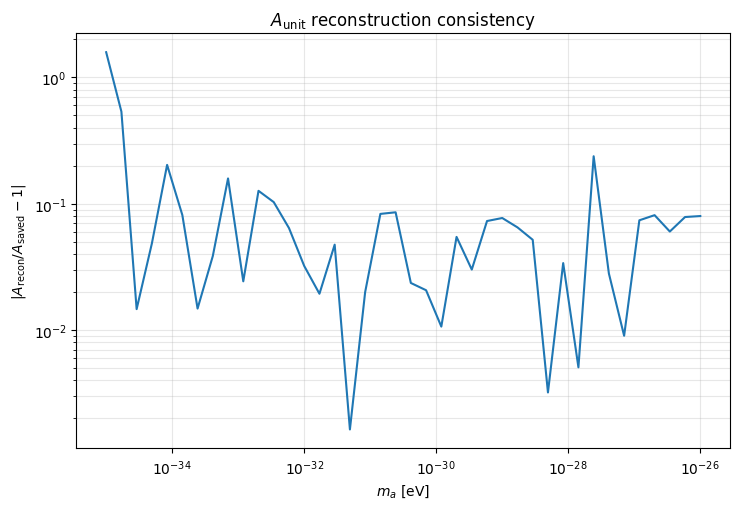

In [2]:
plt.figure(figsize=(7.5, 5.2))
plt.loglog(masses, rel_diff_A)
plt.xlabel(r"$m_a\ [{\rm eV}]$")
plt.ylabel(r"$|A_{\rm recon}/A_{\rm saved}-1|$")
plt.title(r"$A_{\rm unit}$ reconstruction consistency")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()
        


## kinetic / potential fraction
        


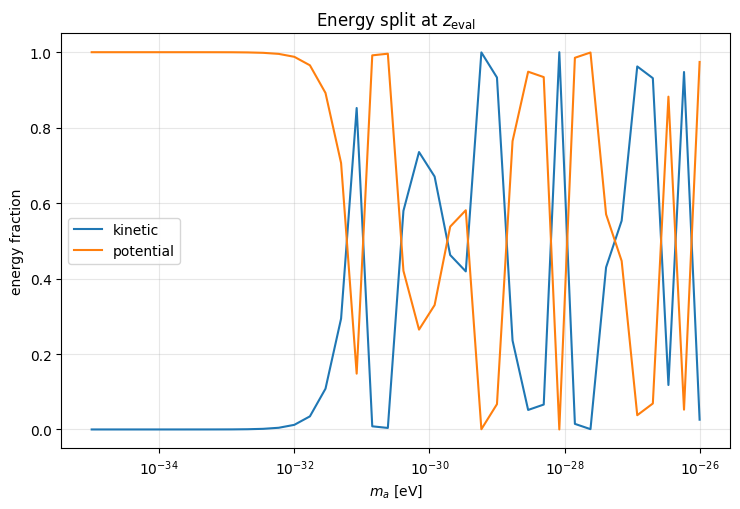

In [3]:
plt.figure(figsize=(7.5, 5.2))
plt.semilogx(masses, kinetic_fraction, label="kinetic")
plt.semilogx(masses, potential_fraction, label="potential")
plt.xlabel(r"$m_a\ [{\rm eV}]$")
plt.ylabel("energy fraction")
plt.title(r"Energy split at $z_{\rm eval}$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
        


## `|A_unit| \phi_{\rm amp,max}` の大きさ
        


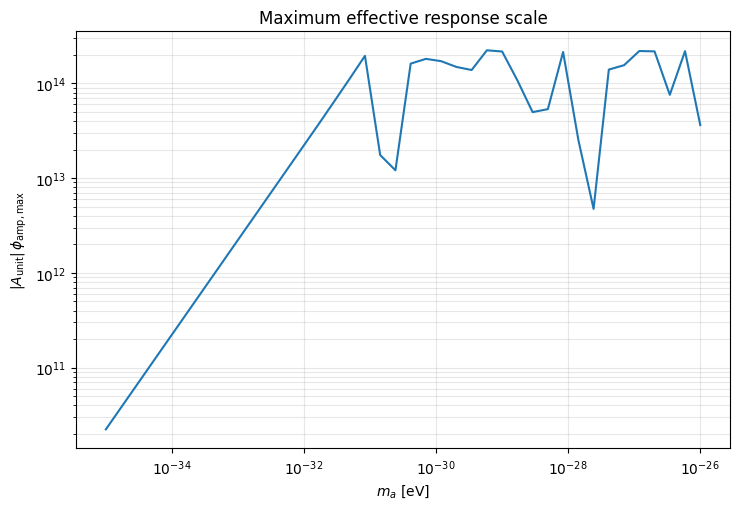

In [4]:
plt.figure(figsize=(7.5, 5.2))
plt.loglog(masses, Aphi)
plt.xlabel(r"$m_a\ [{\rm eV}]$")
plt.ylabel(r"$|A_{\rm unit}|\,\phi_{\rm amp,max}$")
plt.title(r"Maximum effective response scale")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()
        


## 代表値
        


In [5]:
summary = [
    {
        "m_eV": float(row["mass_eV"]),
        "rel_diff_A": float(row["rel_diff_A_unit"]),
        "kinetic_fraction": float(row["kinetic_fraction"]),
        "potential_fraction": float(row["potential_fraction"]),
        "A_times_phi_amp_max": float(row["A_times_phi_amp_max"]),
    }
    for row in rows[::max(len(rows)//8, 1)]
]

summary
        


[{'m_eV': 1e-35,
  'rel_diff_A': 1.5842806518370947,
  'kinetic_fraction': 7.651787255199876e-08,
  'potential_fraction': 0.9999999234821274,
  'A_times_phi_amp_max': 22237063743.557957},
 {'m_eV': 1.4251026703029962e-34,
  'rel_diff_A': 0.08144099932207079,
  'kinetic_fraction': 2.7213318329019935e-06,
  'potential_fraction': 0.9999972786681671,
  'A_times_phi_amp_max': 316900988774.6308},
 {'m_eV': 2.0309176209047304e-33,
  'rel_diff_A': 0.12664645928823215,
  'kinetic_fraction': 0.0005999395082272652,
  'potential_fraction': 0.9994000604917728,
  'A_times_phi_amp_max': 4516497237518.835},
 {'m_eV': 2.89426612471674e-32,
  'rel_diff_A': 0.04749975710898453,
  'kinetic_fraction': 0.10805648013641717,
  'potential_fraction': 0.8919435198635828,
  'A_times_phi_amp_max': 65193928387955.945},
 {'m_eV': 4.124626382901364e-31,
  'rel_diff_A': -0.02362007759205811,
  'kinetic_fraction': 0.5795461029909926,
  'potential_fraction': 0.4204538970090074,
  'A_times_phi_amp_max': 161979788796089.2